# Práctica 2.1. Ejercicio de forward & backward de una RNN

## Bogdan Kaleb García Rivera
### MIA-3
Esta práctica tiene como finalidad realizar los cálculos de una RNN simple. El objetivo principal es entender como funciona una RRN, realizando los cálculos tanto de Forward Propagation como Backward propagation.

En la siguiente imagen se tiene el diagrama de una unidad de red, la cual consta solo de una capa oculta (y retroalimentación) y una salida, así como de tres entradas que en este caso son palabras tokenizadas (por simplicidad se tienen únicamente 3 palabras tokenizadas de tamaño 3). Para cada palabra se hace uso de una unidad de red.  

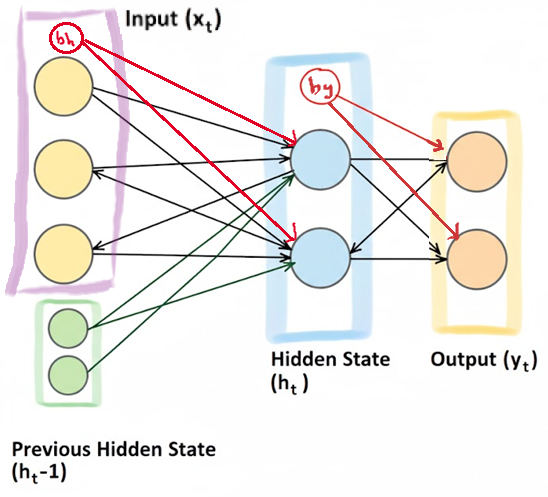

Inicializando las variables.

In [ ]:
import numpy as np
W_x   = np.array([[0.5, 0.6, 0.7],
                [0.8, 0.9, 1.0]])
U   = np.array([[0.1, 0.2],
                [0.3, 0.4]])
b_h  = np.array([0.1, 0.2])
W_y = np.array([[0.2, 0.3],
                [0.4, 0.5]])
b_y = np.array([0.3, 0.4])
h_0  = np.array([0.0, 0.0])

embeddings = np.array([
    [0.1, 0.2, 0.3],
    [0.4, 0.5, 0.6],
    [0.7, 0.8, 0.9]
])

Donde W es la matriz de pesos de la entrada, U la matriz de pesos de la capa oculta, $b_h$ es el bias de la capa oculta, $W_y$ es la matriz de pesos de la salida, $b_y$ es el bias de la salida y $h_0$ es el estado oculto anterior inicializado en ceros. La idea es que ingrese palabras en modos de embeddings y clasifique si la reseña es positiva o negativa.

## Forward

Los estados ocultos (h) se calculan como: $h(t) = \tanh (U * h(t-1) + W_x * x(t) + b_h)$

Recordando que es una secuencia de palabras, se calcula inicialmente el estado oculto de la palabra 1: [0.1,0.2,0.3].

In [ ]:
x_1 = embeddings[0]
op = np.dot(W_x,x_1) + np.dot(U,h_0) + b_h
print("Operación antes de activación tanh: ",op)
h_1 = np.tanh(op)
print("h_1: ",np.round(h_1,3))

Operación antes de activación tanh:  [0.48 0.76]
h_1:  [0.446 0.641]


Posteriormente se calcula el estado oculto de la palabra 2: [0.4,0.5,0.6].

In [ ]:
x_2 = embeddings[1]
op = np.dot(W_x,x_2) + np.dot(U,h_1) + b_h
print("Operación antes de activación tanh: ",op)
h_2 = np.tanh(op)
print("h_2: ",np.round(h_2,3))

Operación antes de activación tanh:  [1.19283975 1.96030387]
h_2:  [0.831 0.961]


Finalmente se realiza el mismo cálculo para la palabra 3: [0.7,0.8,0.9].

In [ ]:
x_3 = embeddings[2]
op = np.dot(W_x,x_3) + np.dot(U,h_2) + b_h
print("Operación antes de activación tanh: ",op)
h_3 = np.tanh(op)
print("h_3: ",np.round(h_3,3))

Operación antes de activación tanh:  [1.83536835 3.01388246]
h_3:  [0.95  0.995]


Las salidas se calculan con la siguiente fórmula: $y(t) = \text{sigmoid}(W_y * h_t + b_y)$ .

In [ ]:
def sigmoide(x):
  return 1/(1 + np.exp(-x))

Para la salida 1 ($y_1$).


In [ ]:
op = np.dot(W_y,h_1) + b_y
print("Operación antes de activación tanh: ",op)
y_1 = sigmoide(op)
print("y_1: ",np.round(y_1,3))

Operación antes de activación tanh:  [0.58157181 0.89903592]
y_1:  [0.641 0.711]


Para la salida 2 ($y_2$).


In [ ]:
op = np.dot(W_y,h_2) + b_y
print("Operación antes de activación tanh: ",op)
y_2 = sigmoide(op)
print("y_2: ",np.round(y_2,3))

Operación antes de activación tanh:  [0.75462541 1.21313951]
y_2:  [0.68  0.771]


Para calcular la salida final, se hace uso de la última capa ya que tiene la retroalimentación de los estados anteriores. En este caso se llamó $y_t$.

In [ ]:
op = np.dot(W_y,h_3) + b_y
print("Operación antes de activación tanh: ",op)
y_t = sigmoide(op)
print("y_t: ",np.round(y_t,3))

Operación antes de activación tanh:  [0.78862667 1.27773436]
y_t:  [0.688 0.782]


## Backward

Para la capa de salida se tiene que calcular el error ($dy_t$), el cual está dado simplemente por la siguiente fórmula: $dy_t = y_t - y_{true}$ donde $y_t$ es la salida predicha y $y_{true}$ la salida esperada.

In [ ]:
y_true = [1,0] #Se asignaron estos valores de ejemplo
dy_t = y_t - y_true
print("Error (dy_t)", np.round(dy_t,3))

Error (dy_t) [-0.312  0.782]


De igual manera, el gradiente en la salida ($ \bigtriangledown \omega_y$) se calcula como: $ \bigtriangledown \omega_y = dy_t \otimes h_3^T$.

In [ ]:
Gwy = np.round(np.outer(dy_t,h_3.T),4)
print("Gradiente Gwy: \n",Gwy)

Gradiente Gwy: 
 [[-0.2969 -0.311 ]
 [ 0.7432  0.7783]]


Y el valor del gradiente del bias en la salida ($\bigtriangledown b_y$) simplemente es el error de $dy_t$ anteriormente calculado, es decir:  $\bigtriangledown b_y = by_t$.

In [ ]:
Gby = dy_t
print("Gradiente Gby: \n",Gby)

Gradiente Gby: 
 [-0.31246363  0.78206387]


Propagación del error de salida a h3. Para este paso, el error manejado en $h_3$ se calcula como: $dh_3 = W_y^T * dy_t$.

In [ ]:
dh_3 = np.dot(W_y.T,dy_t)
print("Error de la capa oculta (dh_3): ", np.round(dh_3,4))

Error de la capa oculta (dh_3):  [0.2503 0.2973]


Es necesario propagar el error a través de la activación (t=3). Para esto se hace uso de una variable de preactivación o temporal. En este caso se llamó $d_{pre\_h3}$. Este error se calcula como $d_{pre\_h3} = (1-h_3^2) ⊙ dh_3$.

In [ ]:
dpre_h3 = (1-h_3**2)*dh_3
print("Error preactivación dpre_h3: ", dpre_h3)

Error preactivación dpre_h3:  [0.02424162 0.00285317]


De igual forma se deben calcular los gradientes con respecto a t=3.

Comenzando con $\bigtriangledown \omega_3= d_{pre\_h3}⊗x_3^T $.

In [ ]:
Gw3 = np.round(np.outer(dpre_h3,x_3.T),4)
print("Gradiente Gw3: \n",Gw3)

Gradiente Gw3: 
 [[0.017  0.0194 0.0218]
 [0.002  0.0023 0.0026]]


Para el calculo del gradiente de la matriz de pesos en t=3:

$\bigtriangledown U_3= d_{pre\_h3}⊗h_2^T $.

In [ ]:
Gu3 = np.round(np.outer(dpre_h3,h_2.T),4)
print("Gradiente Gu3: \n",Gu3)

Gradiente Gu3: 
 [[0.0202 0.0233]
 [0.0024 0.0027]]


De igual manera, para el gradiente del bias en h3: $\bigtriangledown b_h3 = d_{pre\_h3}$.

In [ ]:
Gbh3 = dpre_h3
print("Gradiente Gbh3: \n",Gbh3)

Gradiente Gbh3: 
 [0.02424162 0.00285317]


En este punto, la propagación comienza a realizarse a través de las capas ocultas.

Para el error ($dh_2$), se usa la siguiente fórmula: $dh_2 = U^T*d_{pre\_h3}$.

In [ ]:
dh_2 = np.dot(U.T,dpre_h3)
print("Error dh2: ", dh_2)

Error dh2:  [0.00328011 0.00598959]


Así como se realizó con la capa anterior, se realizan los mismos cálculos de los gradientes.

Para el error de preactivación $d_{pre\_h2}$.

In [ ]:
dpre_h2 = (1-h_2**2)*dh_2
print("Error preactivación dpre_h2: ", dpre_h2)

Error preactivación dpre_h2:  [0.0010125  0.00045678]


Con respecto al gradiente $\bigtriangledown \omega_2$.

In [ ]:
Gw2 = np.round(np.outer(dpre_h2,x_2.T),5)
print("Gradiente Gw2: \n",Gw2)

Gradiente Gw2: 
 [[0.00041 0.00051 0.00061]
 [0.00018 0.00023 0.00027]]


Con respecto al gradiente $\bigtriangledown U_2$.

In [ ]:
Gu2 = np.round(np.outer(dpre_h2,h_1.T),5)
print("Gradiente Gu2: \n",Gu2)

Gradiente Gu2: 
 [[0.00045 0.00065]
 [0.0002  0.00029]]


Para el gradiente del bias $\bigtriangledown b_{h2}$.

In [ ]:
Gbh2 = dpre_h2
print("Gradiente Gbh2: \n",Gbh2)

Gradiente Gbh2: 
 [0.0010125  0.00045678]


Realizando la propagación de $h_2$ a $h_1$.

Se repite el mismo proceso. Calculando la derivada del error $dh_1$.

In [ ]:
dh_1 = np.dot(U.T,dpre_h2)
print("Error de la capa oculta (dh_1): ", np.round(dh_1,6))

Error de la capa oculta (dh_1):  [0.000238 0.000385]


Y se calculan los gradientes finales.

Calculando el error de preactivación $d_{pre\_h1}$.

In [ ]:
dpre_h1 = (1-h_1**2)*dh_1
print("Error preactivación dpre_h1: ", dpre_h1)

Error preactivación dpre_h1:  [0.00019083 0.0002269 ]


Con respecto al gradiente $\bigtriangledown \omega_1$.

In [ ]:
Gw1 = np.round(np.outer(dpre_h1,x_1.T),6)
print("Gradiente Gw1: \n",Gw1)

Gradiente Gw1: 
 [[1.9e-05 3.8e-05 5.7e-05]
 [2.3e-05 4.5e-05 6.8e-05]]


Con respecto al gradiente $\bigtriangledown U_1$ se realiza la propagación con respecto a los pesos

In [ ]:
Gu1 = np.round(np.outer(dpre_h2,h_0.T),6)
print("Gradiente Gu1: \n",Gu1)

Gradiente Gu1: 
 [[0. 0.]
 [0. 0.]]


Y finalmente, para el gradiente del bias $\bigtriangledown b_{h1}$.

In [ ]:
Gbh1 = dpre_h1
print("Gradiente Gbh1: \n",Gbh1)

Gradiente Gbh1: 
 [0.00019083 0.0002269 ]


Los gradientes finales son la suma de todos los gradientes.

In [ ]:
Gw = Gw1 + Gw2 + Gw3
Gu = Gu1 + Gu2 + Gu3
Gbh = Gbh1 + Gbh2 + Gbh3
print("Gradiente Final Gw: \n",Gw)
print("Gradiente Final Gu: \n",Gu)
print("Gradiente Final Gbh: \n",Gbh)

Gradiente Final Gw: 
 [[0.017429 0.019948 0.022467]
 [0.002203 0.002575 0.002938]]
Gradiente Final Gu: 
 [[0.02065 0.02395]
 [0.0026  0.00299]]
Gradiente Final Gbh: 
 [0.02544495 0.00353685]


Finalmente, los gradientes se actualizan con una tasa de aprendizaje y los valores de los gradientes. La fórmula es: $W_{new} = W_{old} - α \bigtriangledown \omega$. Para este caso se usa un valor α = 0.1.

Actualizando los pesos de la salida.

In [ ]:
alpha = 0.1
Wy_new = W_y - alpha * Gwy
by_new = b_y - alpha * Gby

print("Valor del nuevo peso Wy: \n",Wy_new)
print("Valor del nuevo peso by: \n",by_new)

Valor del nuevo peso Wy: 
 [[0.22969 0.3311 ]
 [0.32568 0.42217]]
Valor del nuevo peso by: 
 [0.33124636 0.32179361]


Actualizando los pesos de entrada ($W_x$), ocultos (U) y bias de la capa oculta ($b_h$).  

In [ ]:
Wx_new = W_x - alpha * Gw
U_new = U - alpha * Gu
bh_new = b_h - alpha*Gbh

print("Valor del nuevo peso W: \n",Wx_new)
print("Valor del nuevo peso U: \n",U_new)
print("Valor del nuevo peso bh: \n",bh_new)

Valor del nuevo peso W: 
 [[0.4982571 0.5980052 0.6977533]
 [0.7997797 0.8997425 0.9997062]]
Valor del nuevo peso U: 
 [[0.097935 0.197605]
 [0.29974  0.399701]]
Valor del nuevo peso bh: 
 [0.09745551 0.19964632]


## Conclusión

En este ejercicio se demostró de una manera numérica el ciclo completo de aprendizaje de una Red Neuronal Recurrente (RNN). Se detalló en las fases de forward, backward y la actualización de los pesos principalmente. El  objetivo principal fue entender más a detalle como funciona una RNN, logrando así la meta propuesta.